<a href="https://colab.research.google.com/github/DahliaHye/Multi-Armed-Bandits/blob/main/Multi_Armed_Bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. 환경 설정: 각 슬롯머신의 실제 평균 보상 (승률)
# 우리는 4번째 머신(0.8)이 가장 좋다는 것을 알지만, 인공지능은 학습을 통해 이를 알아내야 합니다.
true_rewards = [0.2, 0.5, 0.1, 0.8, 0.3]
n_arms = len(true_rewards)

# 2. 보상 지급 함수 (베르누이 분포)
def get_reward(arm_index):
    """
    선택한 머신의 승률에 따라 1점 또는 0점을 반환합니다.
    예: 승률이 0.8인 머신은 80% 확률로 1을 반환합니다.
    """
    if np.random.random() < true_rewards[arm_index]:
        return 1  # 당첨
    else:
        return 0  # 꽝

# 잘 작동하는지 테스트 (4번 머신을 10번 당겨보기)
test_results = [get_reward(3) for _ in range(10)]
print(f"4번 머신(승률 0.8) 10번 테스트 결과: {test_results}")

4번 머신(승률 0.8) 10번 테스트 결과: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0]


In [ ]:
def run_mab_experiment(epsilon, n_steps=1000):
    # 각 머신을 선택한 횟수 저장 (0으로 초기화)
    counts = np.zeros(n_arms)
    # 각 머신의 예상 평균 보상 저장 (0으로 초기화)
    estimated_values = np.zeros(n_arms)

    # 결과를 기록할 리스트
    cumulative_rewards = []
    total_reward = 0
    arm_history = [] # 어떤 머신을 선택했었는지 기록

    for i in range(1, n_steps + 1):
        # --- 전략 결정 부분 ---
        if np.random.random() < epsilon:
            # [탐색] 무작위로 아무거나 선택
            chosen_arm = np.random.randint(n_arms)
        else:
            # [활용] 현재까지 추측한 평균값이 가장 높은 머신 선택
            # 값이 모두 0일 때는 가장 첫 번째 머신이 선택되는 걸 방지하기 위해 무작위성 살짝 추가
            chosen_arm = np.argmax(estimated_values + np.random.randn(n_arms) * 0.0001)

        # 보상 획득
        reward = get_reward(chosen_arm)

        # 데이터 업데이트 (점진적 평균 계산 공식)
        counts[chosen_arm] += 1
        # 새로운 평균 = 이전 평균 + (이번 보상 - 이전 평균) / 선택 횟수
        estimated_values[chosen_arm] += (reward - estimated_values[chosen_arm]) / counts[chosen_arm]

        # 누적 기록
        total_reward += reward
        cumulative_rewards.append(total_reward)
        arm_history.append(chosen_arm)

    return cumulative_rewards, counts, estimated_values

# --- 3가지 전략으로 실험 실행 ---
# 1. Random (epsilon=1.0: 100% 무작위 탐험)
rewards_rand, counts_rand, values_rand = run_mab_experiment(epsilon=1.0)

# 2. Greedy (epsilon=0.0: 탐험 없음, 현재 최고만 선택)
rewards_greedy, counts_greedy, values_greedy = run_mab_experiment(epsilon=0.0)

# 3. ε-greedy (epsilon=0.1: 10% 탐험)
rewards_eps01, counts_eps01, values_eps01 = run_mab_experiment(epsilon=0.1)

print("실험이 완료되었습니다!")
print(f"Greedy 전략이 추측한 4번 머신의 승률: {values_greedy[3]:.2f}")
print(f"e-Greedy 전략이 추측한 4번 머신의 승률: {values_eps01[3]:.2f}")

실험이 완료되었습니다!
Greedy 전략이 추측한 4번 머신의 승률: 0.78
e-Greedy 전략이 추측한 4번 머신의 승률: 0.82


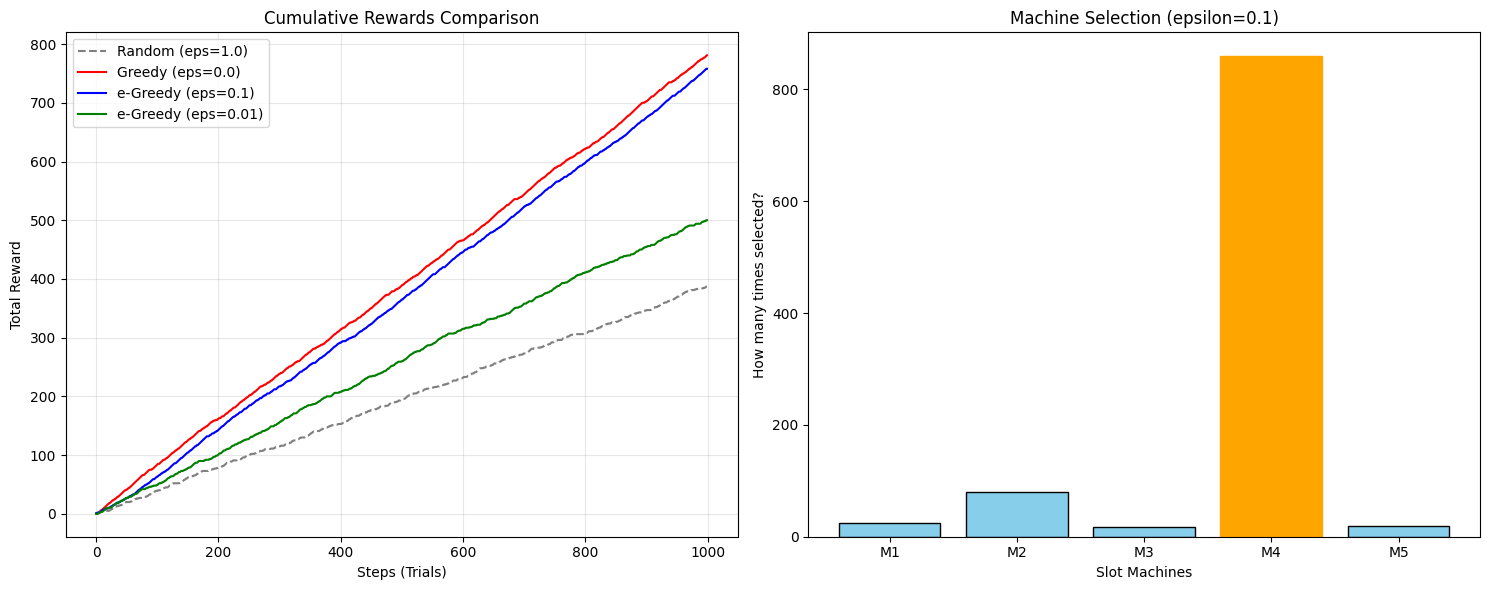

최종 수익 - Random: 387
최종 수익 - Greedy: 781
최종 수익 - e-Greedy (0.1): 758
최종 수익 - e-Greedy (0.01): 500


In [4]:
# --- 추가 실험: epsilon=0.01 실행 ---
rewards_eps001, counts_eps001, _ = run_mab_experiment(epsilon=0.01)

# --- 시각화 설정 ---
plt.figure(figsize=(15, 6))

# 1. 누적 보상 곡선 (Cumulative Reward Curve)
plt.subplot(1, 2, 1)
plt.plot(rewards_rand, label='Random (eps=1.0)', color='gray', linestyle='--')
plt.plot(rewards_greedy, label='Greedy (eps=0.0)', color='red')
plt.plot(rewards_eps01, label='e-Greedy (eps=0.1)', color='blue')
plt.plot(rewards_eps001, label='e-Greedy (eps=0.01)', color='green')
plt.xlabel('Steps (Trials)')
plt.ylabel('Total Reward')
plt.title('Cumulative Rewards Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 머신별 선택 횟수 (Selection Counts - e-Greedy 0.1 기준)
plt.subplot(1, 2, 2)
machine_names = ['M1', 'M2', 'M3', 'M4', 'M5']
plt.bar(machine_names, counts_eps01, color='skyblue', edgecolor='black')
plt.xlabel('Slot Machines')
plt.ylabel('How many times selected?')
plt.title('Machine Selection (epsilon=0.1)')

# M4(Index 3)가 정답이므로 강조 표시
plt.gca().get_children()[3].set_color('orange')

plt.tight_layout()
plt.show()

# 최종 누적 수익 비교 출력
print(f"최종 수익 - Random: {rewards_rand[-1]}")
print(f"최종 수익 - Greedy: {rewards_greedy[-1]}")
print(f"최종 수익 - e-Greedy (0.1): {rewards_eps01[-1]}")
print(f"최종 수익 - e-Greedy (0.01): {rewards_eps001[-1]}")